In [ ]:
import string
import pandas as pd
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

## Download NLTK's resources if they are not present in local machine.

In [ ]:
def init_nltk_resources():
    nltk.download('stopwords')
    nltk.download('punkt')
    nltk.download('wordnet')
    nltk.download('omw-1.4')

In [ ]:
init_nltk_resources()

## Performs

#### 1. punctuation-removal

#### 2. stopwords-removal

#### 3. lemmatization


In [ ]:
def preprocess(docs):
    clean_docs = []

    # get a lemmatizer object from NLTK
    lemma = WordNetLemmatizer()

    # get NLTK's list of stopwords
    stop_words = stopwords.words('english')

    # create a mapper that replaces punctuations (defined
    # in string.punctuation) to an empty string
    punc = str.maketrans('', '', string.punctuation)

    for doc in docs:
        # remove punctuation
        doc_no_punc = doc.translate(punc)
        # convert all characters to lowercase (normalization)
        words = doc_no_punc.lower().split()

        # any word that is not found in NLTK's list of stopwords
        # is lemmatized to its root-form ('v' means 'verb')
        # and stored in the 'words' array
        words = [lemma.lemmatize(word, 'v')
                    for word in words if word not in stop_words]

        # join each word in our list to form back a document
        clean_docs.append(' '.join(words))

    return clean_docs

## Function - BOW
### Performs Bag-Of-Words to extract features from our corpus.

In [ ]:
def BOW(docs):
    bow = CountVectorizer()

    # fit → learn vocabulary from docs
    # transform → convert docs into vectors
    # toarray() transforms results in a sparse matrix form to a dense matrix form
    feature_vectors = bow.fit_transform(docs).toarray()

    # returning both feature-vectors and feature-names. the
    # feature-vectors are aligned with the feature-names (vocab)
    return feature_vectors, bow.get_feature_names_out()

## Function - pretty_print
### Display feature-vectors along with feature-names (aka - our vocab)

In [ ]:
def pretty_print(feat_vecs, feat_names):
    df = pd.DataFrame(data=feat_vecs,
            index=['doc1', 'doc2', 'doc3'],
            columns=feat_names)

    print(df)

## Preprocess documents

In [ ]:
docs = [
    'John has some cats.',
    'Cats, being cats, eat fish.',
    'I ate a big fish.'
]

# data cleansing
clean_docs = preprocess(docs)
print(clean_docs)

## BOW Example

In [ ]:
# getting feature-vectors and feature-names from
# after our BOW process
feat_vecs, feat_names = BOW(clean_docs)

In [ ]:
print(feat_vecs)

In [ ]:
print(feat_names)

In [ ]:
# display the count-frequencies against the
# vocabulary (features) and documents
pretty_print(feat_vecs, feat_names)

## Function TF-IDF
### Performs TF-IDF to extract features from our corpus.

In [ ]:
def TF_IDF(docs):
    tfidf = TfidfVectorizer()

    # toarray() transforms results in a sparse matrix form
    # to a dense matrix form
    # feature_vectors = tfidf.fit(docs).transform(docs).toarray()
    feature_vectors = tfidf.fit_transform(docs).toarray()

    # returning both feature-vectors and feature-names. the
    # feature-vectors are aligned with the feature-names (vocab)
    return feature_vectors, tfidf.get_feature_names_out()

## TF-IDF Example

In [ ]:
# getting feature-vectors and feature-names from
# after our TF-IDF process
feat_vecs, feat_names = TF_IDF(clean_docs)

In [ ]:
print(feat_vecs)

In [ ]:
print(feat_names)

In [ ]:
pretty_print(feat_vecs, feat_names)

## Cosine Similarity Example
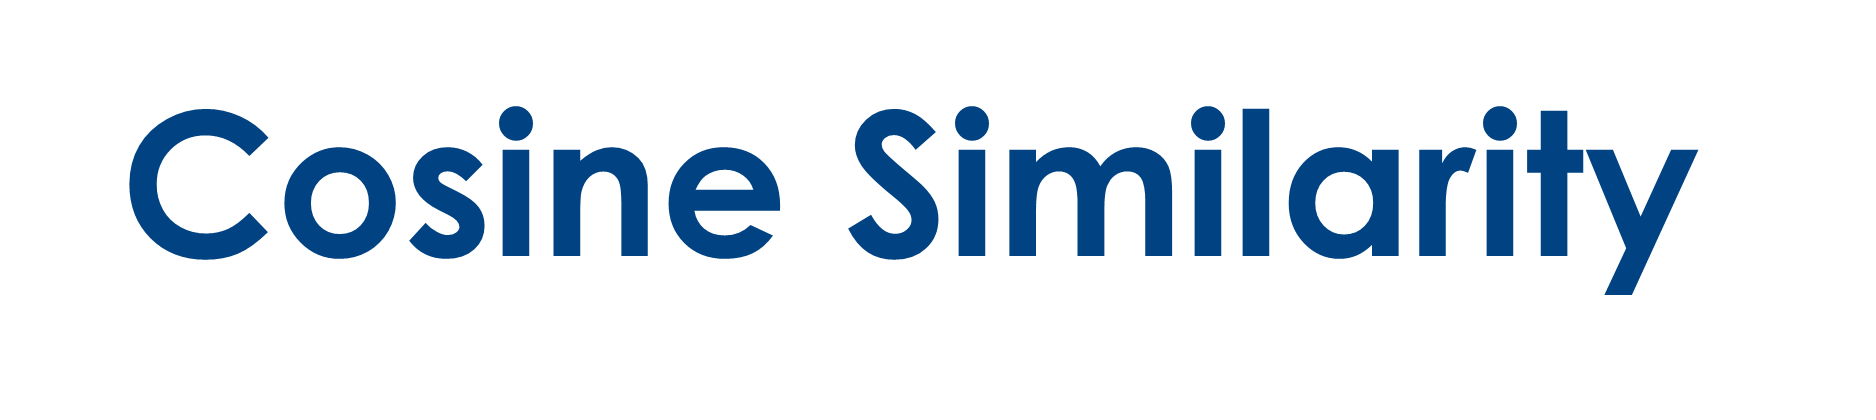

In [ ]:
clean_docs

In [ ]:
query = ['cats and fish']
clean_query = preprocess(query)
clean_query

In [ ]:
# compute normalized TF-IDF
tfidf = TfidfVectorizer()
tfidf.fit(clean_docs)

fv_corpus = tfidf.transform(clean_docs).toarray()
fv_query = tfidf.transform(clean_query).toarray()

fv = pd.DataFrame(data=fv_query,
                  index=['query string'],
                  columns=tfidf.get_feature_names_out())

print(fv, '\n')

In [ ]:
#compute cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(fv_query, fv_corpus)

cs = pd.DataFrame(data=similarity,
                  index=['cosine similarity'],
                  columns=['doc1', 'doc2', 'doc3'])

print(cs)
